# Week 12: The ML Lifecycle, End to End

AIE683 Machine Learning, Hacettepe University

This notebook walks through one full turn of the production loop on a small, simulated
customer-churn problem:

1. train two candidate models and log them to MLflow (with signatures and input examples),
2. register the best one and give it the `champion` alias,
3. load it back as `models:/churn-classifier@champion`,
4. score a table in **batch** and serve **online** predictions through a FastAPI app
   (tested in-process with `TestClient`, no server needed),
5. log every prediction, simulate six months of production traffic with drift,
6. compute drift signals (KS, PSI, a classifier two-sample test, outlier rates from
   IsolationForest / LocalOutlierFactor / OneClassSVM) and log them to MLflow,
7. retrain a `challenger`, compare it with the champion on fresh labeled data, and move the alias.

Everything runs on CPU in a minute or two. The data is simulated so that we know the ground
truth: we *built* the drift in, and we can check whether our monitoring finds it.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"   # keep CPU use modest on shared machines

import logging
import tempfile
import uuid
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
from mlflow.models import infer_signature

from scipy.stats import ks_2samp
from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

# Keep the output readable: MLflow's integer-column hint and informational logs are expected here.
warnings.filterwarnings("ignore", message=".*Integer columns in Python cannot represent.*")
warnings.filterwarnings("ignore", message=".*httpx.*")
logging.getLogger("mlflow").setLevel(logging.ERROR)

SEED = 0
rng = np.random.default_rng(SEED)
print("mlflow", mlflow.__version__)

/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mlflow 3.16.1


## 0. Tracking setup

We keep the tracking database and the artifacts in a fresh temporary directory, so every run of
the notebook starts with an empty registry (version numbers start at 1).
Set `PERSIST = True` to write to `mlflow.db` / `mlruns/` next to the notebook instead (both are
git-ignored) and then inspect everything in the UI with

```bash
cd weeks/week12-ml-lifecycle && uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

In [2]:
PERSIST = False

if PERSIST:
    tracking_dir = Path(".").resolve()
else:
    tracking_dir = Path(tempfile.mkdtemp(prefix="week12-mlflow-"))

mlflow.set_tracking_uri(f"sqlite:///{tracking_dir / 'mlflow.db'}")
EXPERIMENT = "week12-ml-lifecycle"
if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=(tracking_dir / "mlruns").as_uri())
mlflow.set_experiment(EXPERIMENT)
client = mlflow.MlflowClient()
print("tracking in", tracking_dir)

tracking in /var/folders/hc/85k2wv2n3d15w48wn16s1xp40000gn/T/week12-mlflow-r9yclxyf


## 1. A simulated churn problem with drift built in

Each customer has six numeric features. The probability of churning follows a logistic model.
Production data arrives month by month. We build in two kinds of change:

* **data drift** (the distribution of X changes): after a price increase, `monthly_charges`
  rises by a few units every month, and support calls become more frequent;
* **concept drift** (P(y | X) changes): from month 4 on, a competitor targets our loyal
  customers and pays their contract exit fees. Long tenure and yearly contracts no longer protect
  against churn, so the *same* customer now has a different churn risk.

Month 0 is the reference period we train on.

In [3]:
FEATURES = ["tenure_months", "monthly_charges", "support_calls",
            "num_products", "contract_yearly", "age"]


def make_customers(n: int, month: int = 0, rng=rng) -> pd.DataFrame:
    """Simulate one month of customers. month=0 is the reference period."""
    charge_shift = 3.0 * month            # data drift: price increase
    call_rate = 1.0 + 0.15 * month        # data drift: more support calls
    new_regime = month >= 4               # concept drift: competitor campaign from month 4

    df = pd.DataFrame({
        "tenure_months": rng.exponential(24, n).round(1),
        "monthly_charges": rng.normal(70 + charge_shift, 15, n).clip(20, None).round(2),
        "support_calls": rng.poisson(call_rate, n),
        "num_products": rng.integers(1, 5, n),
        "contract_yearly": rng.binomial(1, 0.4, n),
        "age": rng.normal(45, 12, n).clip(18, 90).round(0),
    })
    logit = (-1.0
             + 0.03 * (df.monthly_charges - 70)
             + (0.0 if new_regime else -0.04) * df.tenure_months   # loyalty no longer protects
             + 0.45 * df.support_calls
             - 0.3 * df.num_products
             + (-0.3 if new_regime else -1.2) * df.contract_yearly  # competitor buys out contracts
             + (0.8 if new_regime else 0.0))
    df["churn"] = rng.binomial(1, 1 / (1 + np.exp(-logit)))
    df["month"] = month
    return df


reference = make_customers(6000, month=0)
X_ref, y_ref = reference[FEATURES], reference["churn"]
X_train, X_val, y_train, y_val = train_test_split(
    X_ref, y_ref, test_size=0.25, random_state=SEED, stratify=y_ref)
print(X_train.dtypes.to_dict())
print(f"churn rate in reference data: {y_ref.mean():.3f}")
reference.head()

{'tenure_months': dtype('float64'), 'monthly_charges': dtype('float64'), 'support_calls': dtype('int64'), 'num_products': dtype('int64'), 'contract_yearly': dtype('int64'), 'age': dtype('float64')}
churn rate in reference data: 0.104


,tenure_months,monthly_charges,support_calls,num_products,contract_yearly,age,churn,month
0,16.3,74.91,0,4,0,61.0,0,0
1,24.5,59.94,1,4,0,70.0,0,0
2,0.5,61.15,1,3,1,36.0,0,0
3,0.1,81.68,1,4,0,46.0,0,0
4,13.2,65.76,1,1,0,44.0,1,0


## 2. Train candidates and log them as MLflow Models

We compare two candidates, as in Week 8, and log each one as a **model** with

* a **signature** (input and output schema), inferred from data,
* an **input example**,
* the training data as a logged **dataset** (MLflow stores a digest, so we can later tell which
  data a model saw).

We serve churn *probabilities*, so we log the model with `pyfunc_predict_fn="predict_proba"`.
MLflow 3 serializes scikit-learn models with **skops**, which only loads types it trusts;
`HistGradientBoostingClassifier` needs one internal type listed explicitly.

In [4]:
TRUSTED = ["sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor"]
# Pin the serving environment explicitly. Without this, MLflow infers the requirements (in a uv
# project it exports the whole lock file), which is correct but slow and far larger than needed.
import sklearn
REQUIREMENTS = [f"scikit-learn=={sklearn.__version__}", f"pandas=={pd.__version__}",
                f"numpy=={np.__version__}"]
candidates = {
    "logreg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "hgb": HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=SEED),
}
train_ds = mlflow.data.from_pandas(reference.loc[X_train.index], targets="churn",
                                   name="reference-month0")

results = {}
for name, model in candidates.items():
    with mlflow.start_run(run_name=f"train-{name}") as run:
        model.fit(X_train, y_train)
        proba_val = model.predict_proba(X_val)[:, 1]
        metrics = {"val_auc": roc_auc_score(y_val, proba_val),
                   "val_accuracy": accuracy_score(y_val, proba_val > 0.5)}
        mlflow.log_input(train_ds, context="training")
        mlflow.log_params({"model": name, "n_train": len(X_train)})
        mlflow.log_metrics(metrics)
        signature = infer_signature(X_train, model.predict_proba(X_train.iloc[:5]))
        info = mlflow.sklearn.log_model(
            model, name="model", signature=signature,
            input_example=X_train.iloc[:5],
            pyfunc_predict_fn="predict_proba",
            pip_requirements=REQUIREMENTS,
            skops_trusted_types=TRUSTED if name == "hgb" else None,
        )
        results[name] = {"run_id": run.info.run_id, "model_uri": info.model_uri, **metrics}

pd.DataFrame(results).T

,run_id,model_uri,val_auc,val_accuracy
logreg,69390b63cf95498bac4b1c7d6eaa2f4f,models:/m-543e1a7ca3074f7b9dc3afac6eaedd95,0.787303,0.898
hgb,122ef6caa8ac4c73892ae5c79b12a2e7,models:/m-df4755c274634bd78e408693f65764b4,0.740513,0.892667


## 3. Register the best candidate and set the `champion` alias

The registry assigns a version number; the alias is the stable name that serving code uses.

In [5]:
MODEL_NAME = "churn-classifier"
best = max(results, key=lambda k: results[k]["val_auc"])
print("best candidate:", best)

mv1 = mlflow.register_model(results[best]["model_uri"], MODEL_NAME)
client.set_registered_model_alias(MODEL_NAME, "champion", mv1.version)
client.set_model_version_tag(MODEL_NAME, mv1.version, "trained_on", "month 0")
client.set_model_version_tag(MODEL_NAME, mv1.version, "val_auc",
                             f"{results[best]['val_auc']:.4f}")

champ = client.get_model_version_by_alias(MODEL_NAME, "champion")
print(f"champion = version {champ.version}, from run {champ.run_id}")

best candidate: logreg
champion = version 1, from run 69390b63cf95498bac4b1c7d6eaa2f4f


Successfully registered model 'churn-classifier'.
Created version '1' of model 'churn-classifier'.


## 4. Load by alias and look at the signature

Code that loads `models:/churn-classifier@champion` never needs to know the version number.
The signature is enforced at prediction time.

In [6]:
model = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@champion")
print(model.metadata.get_input_schema())
print(model.metadata.get_output_schema())
model.predict(X_val.iloc[:3])

['tenure_months': double (required), 'monthly_charges': double (required), 'support_calls': long (required), 'num_products': long (required), 'contract_yearly': long (required), 'age': double (required)]
[Tensor('float64', (-1, 2))]


array([[0.91874461, 0.08125539],
       [0.91541492, 0.08458508],
       [0.8233018 , 0.1766982 ]])

In [7]:
# Schema enforcement: a request with a missing column is rejected before it reaches the model.
try:
    model.predict(X_val.iloc[:3].drop(columns="support_calls"))
except mlflow.exceptions.MlflowException as e:
    print("rejected:", str(e)[:160], "...")

rejected: Failed to enforce schema of data '      tenure_months  monthly_charges  num_products  contract_yearly   age
5570            1.0            69.15             4   ...


## 5. Batch inference

Batch scoring: load the model once, score a whole table, write the scores together with the
model version. Here we score the first production month and log the result as an artifact.

In [8]:
month1 = make_customers(2000, month=1)
scores = model.predict(month1[FEATURES])[:, 1]
batch_out = month1[FEATURES].assign(churn_score=scores, model_version=champ.version)
batch_path = tracking_dir / "batch_scores_month1.parquet"
batch_out.to_parquet(batch_path)

with mlflow.start_run(run_name="batch-scoring-month1"):
    mlflow.log_params({"model_uri": f"models:/{MODEL_NAME}@champion",
                       "model_version": champ.version, "n_rows": len(batch_out)})
    mlflow.log_metric("mean_churn_score", float(scores.mean()))
    mlflow.log_artifact(str(batch_path), artifact_path="batch")
batch_out.head()

,tenure_months,monthly_charges,support_calls,num_products,contract_yearly,age,churn_score,model_version
0,6.8,72.29,0,1,1,53.0,0.058840,1
1,9.8,89.98,0,2,0,38.0,0.194104,1
2,7.2,87.94,2,3,1,52.0,0.163630,1
3,2.5,72.78,0,2,1,45.0,0.053789,1
4,117.0,79.08,2,2,0,41.0,0.006319,1


## 6. Online inference with FastAPI

The app loads the model **once** at startup (resolving the alias to a concrete version), validates
each request with pydantic, returns the model version with every answer, and appends every
prediction to a log. In production that log would go to a database or a message queue;
here it is a list we can turn into a DataFrame.

`TestClient` calls the app in-process, so no server has to run.

In [9]:
from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel, Field


class Customer(BaseModel):
    tenure_months: float = Field(ge=0)
    monthly_charges: float = Field(ge=0)
    support_calls: int = Field(ge=0)
    num_products: int = Field(ge=1)
    contract_yearly: int = Field(ge=0, le=1)
    age: float = Field(ge=18)


PREDICTION_LOG: list[dict] = []


def create_app(model_name: str, alias: str = "champion") -> FastAPI:
    version = client.get_model_version_by_alias(model_name, alias).version
    loaded = mlflow.pyfunc.load_model(f"models:/{model_name}/{version}")
    app = FastAPI(title="churn-service")

    @app.get("/health")
    def health() -> dict:
        return {"status": "ok", "model": model_name, "version": version}

    @app.post("/predict")
    def predict(customers: list[Customer]) -> dict:
        request_id = str(uuid.uuid4())
        X = pd.DataFrame([c.model_dump() for c in customers])[FEATURES]
        proba = loaded.predict(X)[:, 1]
        now = datetime.now(timezone.utc).isoformat()
        for row, p in zip(X.to_dict("records"), proba):
            PREDICTION_LOG.append({**row, "churn_score": float(p), "model_version": version,
                                   "request_id": request_id, "timestamp": now})
        return {"request_id": request_id, "model_version": version,
                "churn_probability": proba.round(4).tolist()}

    return app


api = TestClient(create_app(MODEL_NAME))
print(api.get("/health").json())

one = X_val.iloc[[0]].to_dict("records")
r = api.post("/predict", json=one)
print(r.status_code, r.json())

{'status': 'ok', 'model': 'churn-classifier', 'version': 1}


200 {'request_id': '951581cf-f3b3-4601-9005-3b8dfae485f8', 'model_version': 1, 'churn_probability': [0.0813]}


In [10]:
# Invalid input is rejected by pydantic with HTTP 422 before the model is called.
bad = [{**one[0], "contract_yearly": 3}]
r = api.post("/predict", json=bad)
print(r.status_code, r.json()["detail"][0]["msg"])

422 Input should be less than or equal to 1


## 7. Six months of production traffic

We send each month's customers through the API. Labels (did the customer churn?) arrive later;
we keep them aside and join them back when they "arrive".

In [11]:
PREDICTION_LOG.clear()
production = {m: make_customers(2000, month=m) for m in range(1, 7)}

for m, df in production.items():
    records = df[FEATURES].to_dict("records")
    for start in range(0, len(records), 250):            # requests of 250 customers
        r = api.post("/predict", json=records[start:start + 250])
        assert r.status_code == 200

log = pd.DataFrame(PREDICTION_LOG)
log["month"] = np.repeat(list(production), [len(d) for d in production.values()])
print(log.shape)
log.tail(3)

(12000, 11)


,tenure_months,monthly_charges,support_calls,num_products,contract_yearly,age,churn_score,model_version,request_id,timestamp,month
11997,10.7,88.25,3,2,1,38.0,0.277758,1,5e0380c9-8379-483d-a287-3864c832d452,2026-09-30T04:12:35.498776+00:00,6
11998,7.7,79.95,1,3,0,27.0,0.187276,1,5e0380c9-8379-483d-a287-3864c832d452,2026-09-30T04:12:35.498776+00:00,6
11999,8.7,81.68,1,2,1,53.0,0.098943,1,5e0380c9-8379-483d-a287-3864c832d452,2026-09-30T04:12:35.498776+00:00,6


## 8. Drift signals

We compare each month's logged inputs with the training data (the **reference**).

* **KS test** per feature: largest gap between the two empirical CDFs.
* **PSI** per feature, with 10 bins from the reference quantiles:
  $\mathrm{PSI} = \sum_i (q_i - p_i)\,\ln(q_i / p_i)$. Rule of thumb: < 0.1 stable,
  0.1–0.25 moderate shift, > 0.25 large shift.
* **Classifier two-sample test**: can a classifier tell reference rows from this month's rows?
  Cross-validated AUC ≈ 0.5 means no detectable drift.
* **Outlier rates** from detectors fitted on the reference data.
* **Prediction drift**: PSI of the model's own scores.

In [12]:
def psi(reference: np.ndarray, current: np.ndarray, n_bins: int = 10, eps: float = 1e-4) -> float:
    """Population Stability Index with bins from reference quantiles."""
    reference, current = np.asarray(reference, float), np.asarray(current, float)
    if np.unique(reference).size <= n_bins:           # discrete feature: one bin per value
        values = np.unique(np.concatenate([reference, current]))
        p = np.array([(reference == v).mean() for v in values])
        q = np.array([(current == v).mean() for v in values])
    else:
        inner = np.unique(np.quantile(reference, np.linspace(0, 1, n_bins + 1)[1:-1]))
        p = np.bincount(np.searchsorted(inner, reference, side="right"),
                        minlength=inner.size + 1) / reference.size
        q = np.bincount(np.searchsorted(inner, current, side="right"),
                        minlength=inner.size + 1) / current.size
    p, q = np.clip(p, eps, None), np.clip(q, eps, None)
    return float(np.sum((q - p) * np.log(q / p)))


def c2st_auc(reference: pd.DataFrame, current: pd.DataFrame, n: int = 2000) -> float:
    """Classifier two-sample test: CV AUC of telling reference rows from current rows."""
    a = reference.sample(n, random_state=SEED)
    b = current.sample(min(n, len(current)), random_state=SEED)
    X = pd.concat([a, b])
    y = np.r_[np.zeros(len(a)), np.ones(len(b))]
    clf = HistGradientBoostingClassifier(max_iter=100, random_state=SEED)
    return float(cross_val_score(clf, X, y, cv=5, scoring="roc_auc").mean())


# Detectors are fitted on the reference inputs only.
# contamination / nu = 0.02: on reference-like data we expect about 2% flagged.
detectors = {
    "isoforest": IsolationForest(contamination=0.02, random_state=SEED),
    "lof": make_pipeline(StandardScaler(),
                         LocalOutlierFactor(n_neighbors=35, contamination=0.02, novelty=True)),
    "ocsvm": make_pipeline(StandardScaler(), OneClassSVM(nu=0.02, gamma="scale")),
}
for det in detectors.values():
    det.fit(X_train)

ref_scores = model.predict(X_train)[:, 1]
baseline_outlier = {k: float((d.predict(X_val) == -1).mean()) for k, d in detectors.items()}
print("outlier rate on held-out reference data:", baseline_outlier)

outlier rate on held-out reference data: {'isoforest': 0.019333333333333334, 'lof': 0.017333333333333333, 'ocsvm': 0.023333333333333334}


In [13]:
rows = []
with mlflow.start_run(run_name="monitoring") as mon_run:
    mlflow.log_params({"model_version": champ.version, "reference": "month 0 (train split)",
                       "psi_bins": 10})
    for m in production:
        X_live = log.loc[log.month == m, FEATURES]
        row = {"month": m}
        for col in FEATURES:
            ks = ks_2samp(X_train[col], X_live[col])
            row[f"ks_{col}"] = ks.statistic
            row[f"ks_pvalue_{col}"] = ks.pvalue
            row[f"psi_{col}"] = psi(X_train[col], X_live[col])
        row["psi_prediction"] = psi(ref_scores, log.loc[log.month == m, "churn_score"])
        row["c2st_auc"] = c2st_auc(X_train, X_live)
        for k, det in detectors.items():
            row[f"outlier_rate_{k}"] = float((det.predict(X_live) == -1).mean())
        mlflow.log_metrics(row, step=m)
        rows.append(row)
    drift = pd.DataFrame(rows).set_index("month")
    mlflow.log_table(log, artifact_file="prediction_log.json")

cols = ["psi_monthly_charges", "psi_support_calls", "psi_tenure_months", "psi_age",
        "psi_prediction", "c2st_auc", "outlier_rate_isoforest", "outlier_rate_lof",
        "outlier_rate_ocsvm"]
drift[cols].round(3)

,psi_monthly_charges,psi_support_calls,psi_tenure_months,psi_age,psi_prediction,c2st_auc,outlier_rate_isoforest,outlier_rate_lof,outlier_rate_ocsvm
month,,,,,,,,,
1,0.048,0.024,0.013,0.004,0.030,0.536,0.014,0.024,0.023
2,0.142,0.079,0.008,0.002,0.095,0.579,0.030,0.037,0.044
3,0.317,0.158,0.010,0.007,0.168,0.628,0.042,0.050,0.054
4,0.600,0.265,0.015,0.006,0.281,0.705,0.048,0.075,0.078
5,0.805,0.431,0.011,0.008,0.471,0.756,0.067,0.094,0.098
6,1.260,0.615,0.002,0.008,0.700,0.818,0.094,0.135,0.128


In [14]:
# The KS p-values: with 2000 vs 4500 rows even small shifts are "significant".
drift[[f"ks_{c}" for c in FEATURES[:3]] + [f"ks_pvalue_{c}" for c in FEATURES[:3]]].round(4)

,ks_tenure_months,ks_monthly_charges,ks_support_calls,ks_pvalue_tenure_months,ks_pvalue_monthly_charges,ks_pvalue_support_calls
month,,,,,,
1,0.0216,0.0867,0.0535,0.5334,0.0,0.0007
2,0.0301,0.1456,0.1093,0.1590,0.0,0.0000
3,0.0177,0.2197,0.1528,0.7701,0.0,0.0000
4,0.0260,0.3102,0.2018,0.3012,0.0,0.0000
5,0.0166,0.3667,0.2613,0.8360,0.0,0.0000
6,0.0133,0.4457,0.3088,0.9649,0.0,0.0000


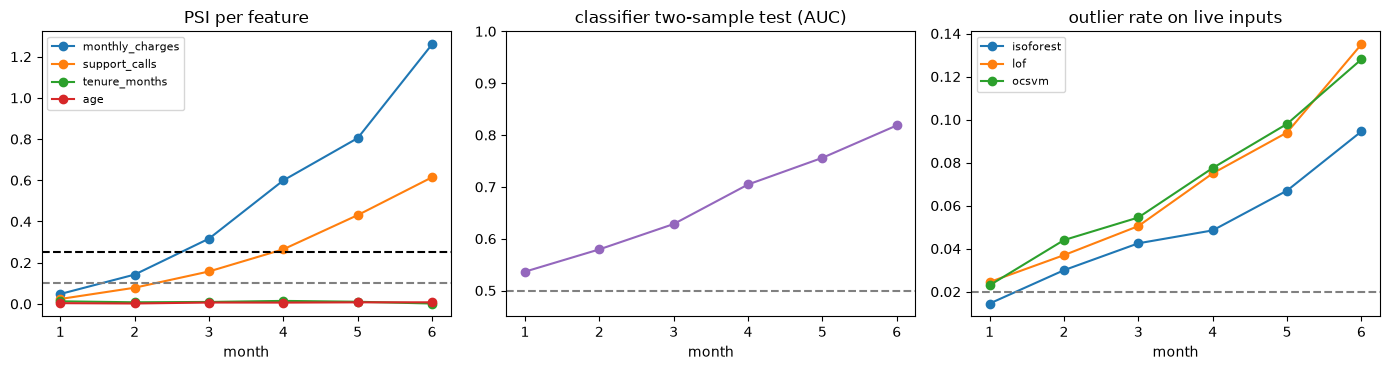

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for col in ["monthly_charges", "support_calls", "tenure_months", "age"]:
    axes[0].plot(drift.index, drift[f"psi_{col}"], marker="o", label=col)
axes[0].axhline(0.1, ls="--", c="gray"); axes[0].axhline(0.25, ls="--", c="k")
axes[0].set(title="PSI per feature", xlabel="month"); axes[0].legend(fontsize=8)

axes[1].plot(drift.index, drift["c2st_auc"], marker="o", c="C4")
axes[1].axhline(0.5, ls="--", c="gray")
axes[1].set(title="classifier two-sample test (AUC)", xlabel="month", ylim=(0.45, 1))

for k in detectors:
    axes[2].plot(drift.index, drift[f"outlier_rate_{k}"], marker="o", label=k)
axes[2].axhline(0.02, ls="--", c="gray")
axes[2].set(title="outlier rate on live inputs", xlabel="month"); axes[2].legend(fontsize=8)
plt.tight_layout()

All input-based signals rise steadily with the price increase. None of them can tell us about
the **concept drift** from month 4: P(X) changes smoothly, and the jump is in P(y | X).
For that we need labels.

The classifier two-sample test also tells us *which* features drifted: ask the drift classifier
for its permutation importances (Week 9), or simply look at the per-feature PSI.

---
## Try it 1: calibrate your PSI alarm (10–15 min)

The thresholds 0.1 / 0.25 are folklore. How large is PSI when **nothing** has changed?
Sampling noise alone gives PSI > 0, and it depends on the sample size and the number of bins.

1. **Predict first:** for a month of 2000 customers drawn from the *reference* distribution
   (`make_customers(2000, month=0)`), what PSI on `monthly_charges` do you expect? Write down a number.
2. Draw 200 such "no-drift months", compute PSI against `X_train` for each, and store the values in
   `null_psi`.
3. Use the 99th percentile as your alarm threshold. In which production month does
   `monthly_charges` first cross it? And with the 0.1 rule?
4. Repeat with `n_bins=20` and with months of 500 customers. What changes?

In [16]:
# ---- Try it 1: exercise cell ----
null_rng = np.random.default_rng(123)
null_psi = []
for _ in range(200):
    no_drift = make_customers(2000, month=0, rng=null_rng)
    # TODO: compute the PSI of no_drift["monthly_charges"] against X_train["monthly_charges"]
    #       and append it to null_psi
    pass

if null_psi:
    threshold = float(np.percentile(null_psi, 99))
    print(f"PSI under no drift: median {np.median(null_psi):.4f}, 99th percentile {threshold:.4f}")
    first = drift.index[drift["psi_monthly_charges"] > threshold]
    print("first month above the calibrated threshold:", first.min() if len(first) else None)
    print("first month above 0.1:", drift.index[drift["psi_monthly_charges"] > 0.1].min())
else:
    print("TODO: fill in the loop above")

TODO: fill in the loop above


## 9. Delayed labels: performance over time

When the churn labels for a month arrive, we join them to the prediction log and compute the
live AUC. This is the signal that catches concept drift.

In [17]:
perf = []
with mlflow.start_run(run_id=mon_run.info.run_id):
    for m, df in production.items():
        s = log.loc[log.month == m, "churn_score"].to_numpy()
        auc = roc_auc_score(df["churn"], s)
        mlflow.log_metrics({"live_auc": auc, "live_churn_rate": df["churn"].mean(),
                            "mean_churn_score": s.mean()}, step=m)
        perf.append({"month": m, "live_auc": auc, "churn_rate": df["churn"].mean(),
                     "mean_score": s.mean()})
perf = pd.DataFrame(perf).set_index("month")
print(f"validation AUC at training time: {results[best]['val_auc']:.3f}")
perf.round(3)

validation AUC at training time: 0.787


,live_auc,churn_rate,mean_score
month,,,
1,0.760,0.121,0.123
2,0.784,0.133,0.147
3,0.776,0.148,0.163
4,0.642,0.515,0.183
5,0.668,0.543,0.213
6,0.648,0.582,0.241


The AUC drops at month 4 and the predicted churn rate falls further and further behind the observed
rate: the model is **miscalibrated** for the new regime. Time to retrain.

## 10. Retrain a challenger

Retraining trigger: live AUC fell clearly below the validation AUC, and the predicted churn rate
no longer matches the observed one. We train the same pipeline as the champion (`clone` keeps the
hyperparameters, drops the fitted state) on the most recent labeled window (months 4 and 5),
log it as a new run, register it as version 2 and give it the `challenger` alias.
Month 6 is kept aside as the comparison set: neither model has seen it.

In [18]:
recent = pd.concat([production[4], production[5]])
X_recent, y_recent = recent[FEATURES], recent["churn"]
holdout = production[6]
X_hold, y_hold = holdout[FEATURES], holdout["churn"]

with mlflow.start_run(run_name=f"train-{best}-challenger") as run:
    challenger = clone(candidates[best]).fit(X_recent, y_recent)
    mlflow.log_input(mlflow.data.from_pandas(recent, targets="churn", name="months-4-5"),
                     context="training")
    mlflow.log_params({"model": best, "n_train": len(X_recent), "window": "months 4-5",
                       "trigger": "live_auc drop + calibration gap"})
    info = mlflow.sklearn.log_model(
        challenger, name="model",
        signature=infer_signature(X_recent, challenger.predict_proba(X_recent.iloc[:5])),
        input_example=X_recent.iloc[:5], pyfunc_predict_fn="predict_proba",
        pip_requirements=REQUIREMENTS,
        skops_trusted_types=TRUSTED if best == "hgb" else None)

mv2 = mlflow.register_model(info.model_uri, MODEL_NAME)
client.set_registered_model_alias(MODEL_NAME, "challenger", mv2.version)
client.set_model_version_tag(MODEL_NAME, mv2.version, "trained_on", "months 4-5")
print("challenger = version", mv2.version)

challenger = version 2


Registered model 'churn-classifier' already exists. Creating a new version of this model...
Created version '2' of model 'churn-classifier'.


## 11. Compare champion and challenger on the same fresh data

Both models are loaded **by alias** and scored on month 6. We use a paired bootstrap
(resample customers, recompute both AUCs on the same resample) to get a confidence interval for
the difference, as in Week 8.

In [19]:
champion_model = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@champion")
challenger_model = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@challenger")
p_champ = champion_model.predict(X_hold)[:, 1]
p_chall = challenger_model.predict(X_hold)[:, 1]

boot_rng = np.random.default_rng(SEED)
y_arr = y_hold.to_numpy()
diffs = []
for _ in range(1000):
    idx = boot_rng.integers(0, len(y_arr), len(y_arr))
    diffs.append(roc_auc_score(y_arr[idx], p_chall[idx]) - roc_auc_score(y_arr[idx], p_champ[idx]))
lo, hi = np.percentile(diffs, [2.5, 97.5])

comparison = {"champion_auc": roc_auc_score(y_hold, p_champ),
              "challenger_auc": roc_auc_score(y_hold, p_chall),
              "auc_diff_ci_low": lo, "auc_diff_ci_high": hi,
              "champion_brier": brier_score_loss(y_hold, p_champ),
              "challenger_brier": brier_score_loss(y_hold, p_chall),
              "champion_mean_score": p_champ.mean(), "challenger_mean_score": p_chall.mean(),
              "observed_churn_rate": y_hold.mean()}
# Decision rule, fixed *before* looking at the numbers: promote only if the whole 95% CI of the
# AUC difference is above zero and the challenger is not worse calibrated (Brier score).
promote = bool(lo > 0 and comparison["challenger_brier"] <= comparison["champion_brier"])

with mlflow.start_run(run_name="champion-vs-challenger"):
    mlflow.log_params({"champion_version": champ.version, "challenger_version": mv2.version,
                       "comparison_data": "month 6", "n_bootstrap": 1000})
    mlflow.log_metrics(comparison)
    mlflow.set_tag("decision", "promote" if promote else "keep champion")

pd.Series(comparison).round(4)

champion_auc             0.6479
challenger_auc           0.6980
auc_diff_ci_low          0.0317
auc_diff_ci_high         0.0694
champion_brier           0.3494
challenger_brier         0.2155
champion_mean_score      0.2413
challenger_mean_score    0.5849
observed_churn_rate      0.5825
dtype: float64

## 12. Promotion = moving an alias

If the challenger is better, `champion` moves to version 2. Version 1 is not deleted: rollback
is one call that moves the alias back. The serving app picks up the new version when it is
(re)started, because it resolves the alias at startup.

In [20]:
if promote:
    client.set_registered_model_alias(MODEL_NAME, "champion", mv2.version)
    client.delete_registered_model_alias(MODEL_NAME, "challenger")
    client.set_model_version_tag(MODEL_NAME, mv2.version, "promoted_at",
                                 datetime.now(timezone.utc).date().isoformat())
    print(f"promoted version {mv2.version} to champion")
else:
    print("challenger not clearly better; champion stays")

print("aliases:", client.get_registered_model(MODEL_NAME).aliases)
for v in client.search_model_versions(f"name='{MODEL_NAME}'"):
    print(f"version {v.version}: tags={v.tags}")

promoted version 2 to champion
aliases: {'champion': 2}
version 2: tags={'trained_on': 'months 4-5', 'promoted_at': '2026-09-30'}
version 1: tags={'trained_on': 'month 0', 'val_auc': '0.7873'}


In [21]:
# Restart the service: it now resolves @champion to the new version.
api = TestClient(create_app(MODEL_NAME))
print(api.get("/health").json())
print(api.post("/predict", json=one).json())

{'status': 'ok', 'model': 'churn-classifier', 'version': 2}
{'request_id': 'f55545c0-57d8-4267-b338-fa0599096929', 'model_version': 2, 'churn_probability': [0.1814]}


In [22]:
# Rollback, if the new champion misbehaves, is one line:
# client.set_registered_model_alias(MODEL_NAME, "champion", mv1.version)

---
## Try it 2: which retraining window wins? Predict, then run (10–15 min)

We retrained on months 4–5 only. Alternatives:

* **expanding window**: all labeled data so far (months 0–5), more data but mostly from the old regime;
* **sliding window**: only the most recent months (what we did);
* **weighted**: all data, but recent months get a larger `sample_weight`.

1. **Predict first:** rank the three options by month-6 AUC. Write your ranking down.
2. Complete the `windows` dictionary below, run the cell, and compare AUC and Brier score.
   Every option is logged as its own MLflow run, so the comparison is recorded.
3. When would the expanding window be the better choice?

In [23]:
# ---- Try it 2: exercise cell ----
labeled = pd.concat([reference] + [production[m] for m in range(1, 6)])
windows = {
    # name: (training rows, sample weights or None)
    "sliding (months 4-5)": (labeled[labeled.month >= 4], None),
    # TODO: add "expanding (months 0-5)" using all rows of `labeled`
    # TODO: add "weighted (months 0-5)" with weight 5.0 for months >= 4 and 1.0 otherwise
}

window_results = {}
for name, (train_rows, weights) in windows.items():
    with mlflow.start_run(run_name=f"window-{name}"):
        m = clone(candidates[best])
        fit_kw = {}
        if weights is not None:  # pipelines route sample_weight to a named step
            key = f"{m.steps[-1][0]}__sample_weight" if hasattr(m, "steps") else "sample_weight"
            fit_kw[key] = weights
        m.fit(train_rows[FEATURES], train_rows["churn"], **fit_kw)
        p = m.predict_proba(X_hold)[:, 1]
        res = {"auc_month6": roc_auc_score(y_hold, p), "brier_month6": brier_score_loss(y_hold, p)}
        mlflow.log_params({"window": name, "n_train": len(train_rows)})
        mlflow.log_metrics(res)
        window_results[name] = res
pd.DataFrame(window_results).T.round(4)

,auc_month6,brier_month6
sliding (months 4-5),0.698,0.2155


## 13. What was logged

Every step of the loop left a trace in MLflow: training runs with datasets and models,
a batch-scoring run, a monitoring run with drift metrics per month and the prediction log,
a new training run, and a comparison run with the promotion decision.

In [24]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT], order_by=["attributes.start_time ASC"])
runs[["tags.mlflow.runName", "metrics.val_auc", "metrics.live_auc",
      "metrics.challenger_auc", "tags.decision"]]

,tags.mlflow.runName,metrics.val_auc,metrics.live_auc,metrics.challenger_auc,tags.decision
0,train-logreg,0.787303,NaN,NaN,NaN
1,train-hgb,0.740513,NaN,NaN,NaN
2,batch-scoring-month1,NaN,NaN,NaN,NaN
3,monitoring,NaN,0.647902,NaN,NaN
4,train-logreg-challenger,NaN,NaN,NaN,NaN
5,champion-vs-challenger,NaN,NaN,0.698048,promote
6,window-sliding (months 4-5),NaN,NaN,NaN,NaN


## Part B: real data. Drift in a bike-sharing system

Now a real dataset: hourly rentals of the Capital Bikeshare system in Washington, D.C.,
2011–2012 (the dataset we used for forecasting in Week 11). We train a demand model on 2011 and
"deploy" it for 2012. Nothing here is simulated, so we do not know the truth in advance.

In [25]:
bike = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True).frame
bike["weather_name"] = bike["weather"].astype(str)
bike["workingday"] = (bike["workingday"] == "True").astype(int)
bike["weather"] = bike["weather"].cat.codes
BIKE_FEATURES = ["hour", "weekday", "workingday", "weather", "temp", "humidity", "windspeed"]

bike_2011 = bike[bike.year == 0]
bike_2012 = bike[bike.year == 1]
bike_model = HistGradientBoostingRegressor(random_state=SEED).fit(
    bike_2011[BIKE_FEATURES], bike_2011["count"])
print(bike.shape, "| trained on", len(bike_2011), "hours of 2011")

(17379, 14) | trained on 8645 hours of 2011


In [26]:
# Monitoring the way a first dashboard usually does it: every 2012 month against all of 2011.
bike_rows = []
for month, live in bike_2012.groupby("month"):
    pred = bike_model.predict(live[BIKE_FEATURES])
    bike_rows.append({
        "month": month,
        "psi_temp_vs_2011": psi(bike_2011["temp"], live["temp"]),
        "psi_humidity_vs_2011": psi(bike_2011["humidity"], live["humidity"]),
        "mae": np.mean(np.abs(live["count"] - pred)),
    })
bike_report = pd.DataFrame(bike_rows).set_index("month")
bike_report.round(3)

,psi_temp_vs_2011,psi_humidity_vs_2011,mae
month,,,
1,3.194,0.159,45.653
2,2.701,0.198,52.221
3,1.337,0.120,80.731
4,1.568,0.602,94.606
5,3.093,0.180,80.766
6,3.178,0.225,93.683
7,4.887,0.082,93.748
8,4.719,0.105,100.433
9,2.999,0.035,115.954


Every month has PSI far above 0.25 for temperature. Is the model broken twelve times a year?
No: one summer month is simply not distributed like a whole year. This is a very common
failure in practice: **a reference window that ignores seasonality produces alarms that
everyone learns to ignore**, and then the real problem goes unnoticed.

---
## Try it 3: drift detective (10–15 min)

1. Add a column `psi_temp_same_month`: PSI of each 2012 month against **the same month of 2011**.
   Which alarms remain?
2. Add a column `bias` = mean(actual − predicted) per month. The labels (rental counts) are
   available with a delay of one day, so this is realistic.
3. Decide: is there data drift, concept drift, or both? What would you do about it? (Hint: compare
   mean demand in 2011 and 2012 for the same weather.)
4. Log your monthly report to MLflow as a run named `bike-monitoring` (one step per month).

In [27]:
# ---- Try it 3: exercise cell ----
for month, live in bike_2012.groupby("month"):
    same_month_2011 = bike_2011[bike_2011.month == month]
    pred = bike_model.predict(live[BIKE_FEATURES])
    # TODO: bike_report.loc[month, "psi_temp_same_month"] = ...
    # TODO: bike_report.loc[month, "bias"] = ...

# TODO: log bike_report to MLflow (mlflow.start_run(run_name="bike-monitoring"),
#       then mlflow.log_metrics(row.to_dict(), step=month) for each month)
bike_report.round(3)

,psi_temp_vs_2011,psi_humidity_vs_2011,mae
month,,,
1,3.194,0.159,45.653
2,2.701,0.198,52.221
3,1.337,0.120,80.731
4,1.568,0.602,94.606
5,3.093,0.180,80.766
6,3.178,0.225,93.683
7,4.887,0.082,93.748
8,4.719,0.105,100.433
9,2.999,0.035,115.954


## Take-home exercises

1. In the churn simulation, make the price increase stop after month 2 but keep the concept drift.
   Which signals still fire?
2. Replace IsolationForest by `sklearn.covariance.EllipticEnvelope`. When is a Gaussian assumption
   good enough for monitoring?
3. Add a field `request_source` (for example `"web"` / `"mobile"`) to the API and log it. How would
   you use it to debug a drift alarm?